3.	Perform logistic regression to classify if a patient has a benign tumor or malignant tumor (cancer) based on the features provided. Utilize gradient descent with regularization for hyper-parameter tuning. Also, generate log-loss curve for this problem.

Dataset: samples_cancer.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("samples_cancer.csv")
df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [ ]:
df = df.replace('?', np.nan).dropna()
df['BareNuc'] = df['BareNuc'].astype(int)

In [ ]:
X = df.drop(columns=['ID', 'Class'])
y = df['Class'].apply(lambda x: 0 if x == 2 else 1).values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
def compute_cost(X, y, theta, lambda_):
    m = len(y)
    h = sigmoid(X @ theta)
    cost = (-1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    reg = (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)  # Regularization
    return cost + reg

In [ ]:
def gradient_descent(X, y, alpha, lambda_, iterations):
    m, n = X.shape
    theta = np.zeros((n, 1))
    y = y.reshape(-1, 1)
    cost_history = []
    for i in range(iterations):
        h = sigmoid(X @ theta)
        error = h - y
        gradient = (1/m) * (X.T @ error) + (lambda_/m) * np.vstack(([0], theta[1:]))
        theta -= alpha * gradient
        cost = compute_cost(X, y, theta, lambda_)
        cost_history.append(cost)

        if i > 0 and abs(cost_history[-2] - cost_history[-1]) < 1e-6:
            print(f"Converged at iteration {i}")
            break

    return theta, cost_history

In [ ]:
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

In [ ]:
theta, cost_history = gradient_descent(X_train_b, y_train, alpha=0.1, lambda_=0.1, iterations=1000)

In [ ]:
y_pred_proba = sigmoid(X_test_b @ theta)
y_pred = (y_pred_proba >= 0.5).astype(int)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9635


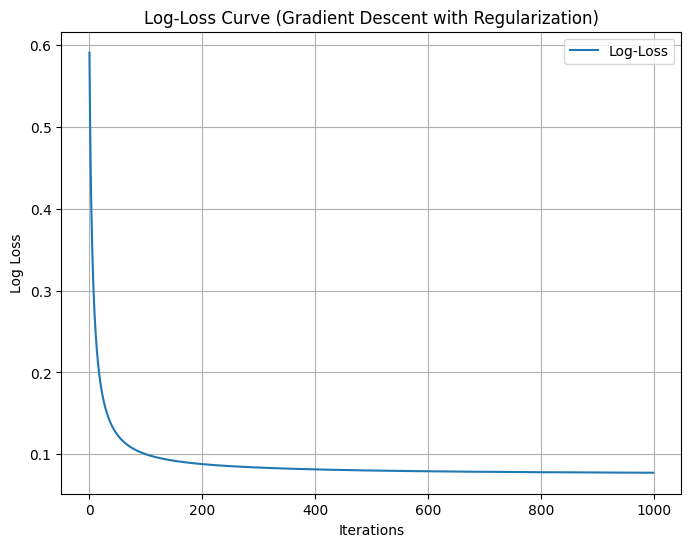

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(cost_history, label="Log-Loss")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Log-Loss Curve (Gradient Descent with Regularization)")
plt.grid(True)
plt.legend()
plt.show()